In [1]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
# os.environ['THEANO_FLAGS'] = "device=cuda0,force_device=True,floatX=float32"
# from aesara_theano_fallback import aesara as theano
#import theano

# print(theano.config.device)
# import sys, getopt
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt



In [17]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"
model = load_model(data_folder+"tbinet.h5")
# model.load_weights("/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/tbinet.12-0.12.hdf5")
model.load_weights("/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/tbinet.22-0.21.hdf5")


In [18]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 147, 4)]     0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 138, 320)     13120       input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling1d (MaxPooling1D)    (None, 134, 320)     0           conv1d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 134, 320)     0           max_pooling1d[0][0]              
______________________________________________________________________________________________

In [19]:
layer_names = [layer.name for layer in model.layers]
layer_names

['input_1',
 'conv1d',
 'max_pooling1d',
 'dropout',
 'dense',
 'permute',
 'activation',
 'permute_1',
 'attention2',
 'repeat_vector',
 'permute_2',
 'multiply',
 'bidirectional',
 'dropout_1',
 'flatten',
 'dense_1',
 'activation_1',
 'dense_2',
 'activation_2']

In [32]:
attention = model.layers[8]
attention

In [20]:
layer_outputs = [layer.output for layer in model.layers]
layer_outputs

[<KerasTensor: shape=(None, 147, 4) dtype=float32 (created by layer 'input_1')>,
 <KerasTensor: shape=(None, 138, 320) dtype=float32 (created by layer 'conv1d')>,
 <KerasTensor: shape=(None, 134, 320) dtype=float32 (created by layer 'max_pooling1d')>,
 <KerasTensor: shape=(None, 134, 320) dtype=float32 (created by layer 'dropout')>,
 <KerasTensor: shape=(None, 134, 1) dtype=float32 (created by layer 'dense')>,
 <KerasTensor: shape=(None, 1, 134) dtype=float32 (created by layer 'permute')>,
 <KerasTensor: shape=(None, 1, 134) dtype=float32 (created by layer 'activation')>,
 <KerasTensor: shape=(None, 134, 1) dtype=float32 (created by layer 'permute_1')>,
 <KerasTensor: shape=(None, 134) dtype=float32 (created by layer 'attention2')>,
 <KerasTensor: shape=(None, 320, 134) dtype=float32 (created by layer 'repeat_vector')>,
 <KerasTensor: shape=(None, 134, 320) dtype=float32 (created by layer 'permute_2')>,
 <KerasTensor: shape=(None, 134, 320) dtype=float32 (created by layer 'multiply')>,

In [34]:
model.input

<KerasTensor: shape=(None, 147, 4) dtype=float32 (created by layer 'input_1')>

In [37]:
attention.output

<KerasTensor: shape=(None, 9) dtype=float32 (created by layer 'attention')>

In [9]:
tf.keras.Input

<function keras.engine.input_layer.Input(shape=None, batch_size=None, name=None, dtype=None, sparse=None, tensor=None, ragged=None, type_spec=None, **kwargs)>

In [21]:
feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

In [22]:
# data_folder = "./data/"
data_folder = "../data/train_test_data/"
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
feature_maps = feature_map_model.predict(np.transpose(testmat['Test_data'],axes=(0,1,2))[:10000])
# feature_maps = model.predict(testmat['Test_data'])

In [23]:
labels = testmat['Test_labels']
print(f"labels.shape: {labels.shape}")
new_labels = labels[0][:10000]
# print(new_labels[0][1])
print(f"new_labels.shape: {new_labels.shape}")
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
print(f'ones.shape {ones.shape}')
print(f'zeros.shape {zeros.shape}')
print(ones)

labels.shape: (1, 150890)
new_labels.shape: (10000,)
ones.shape (3945,)
zeros.shape (6055,)
[   2    3    4 ... 9996 9997 9999]


In [24]:
for layer_name, feature_map in zip(layer_names, feature_maps):print(f"The shape of the {layer_name} is =======>> {feature_map.shape}")

The shape of the input_1 is =======>> (10000, 147, 4)
The shape of the conv1d is =======>> (10000, 138, 320)
The shape of the max_pooling1d is =======>> (10000, 134, 320)
The shape of the dropout is =======>> (10000, 134, 320)
The shape of the dense is =======>> (10000, 134, 1)
The shape of the permute is =======>> (10000, 1, 134)
The shape of the activation is =======>> (10000, 1, 134)
The shape of the permute_1 is =======>> (10000, 134, 1)
The shape of the attention2 is =======>> (10000, 134)
The shape of the repeat_vector is =======>> (10000, 320, 134)
The shape of the permute_2 is =======>> (10000, 134, 320)
The shape of the multiply is =======>> (10000, 134, 320)
The shape of the bidirectional is =======>> (10000, 134, 640)
The shape of the dropout_1 is =======>> (10000, 134, 640)
The shape of the flatten is =======>> (10000, 85760)
The shape of the dense_1 is =======>> (10000, 695)
The shape of the activation_1 is =======>> (10000, 695)
The shape of the dense_2 is =======>> (1000

In [13]:
def plot_feature_map(y, plt_title):
    plt.rcParams["figure.figsize"] = 5,2
    x = range(1,135)

    fig, (ax,ax2) = plt.subplots(nrows=2, sharex=True)

    extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
    ax.imshow(y[np.newaxis,:], cmap="plasma", aspect="auto", extent=extent)
    ax.set_yticks([])
    ax.set_xlim(extent[0], extent[1])

    ax2.plot(x,y)
    fig.suptitle(plt_title)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_both_feature_maps(y0, y1, plt_title):
    plt.rcParams["figure.figsize"] = 10,4
    x = range(1,135)
    data = np.concatenate(([y0], [y1]))
#     print(data)
    fig, axis = plt.subplots()

    extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
    heatmap = axis.pcolor(data, cmap="Blues") 
    axis.set_yticks(np.arange(data.shape[0])+0.5, minor=False)
#     axis.set_xticks(np.arange(data.shape[1])+0.5, 5)
    
    row_labels = ["Depleted - 0", "Enriched - 1"]
    axis.set_yticklabels(row_labels)
#     axis.set_xticklabels(x, 5)
    fig.suptitle(plt_title)
    plt.colorbar(heatmap)
    plt.tight_layout()
    plt.show()

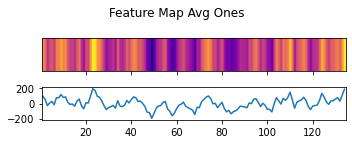

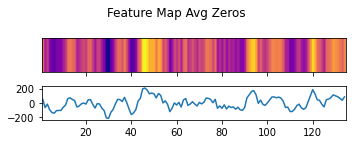

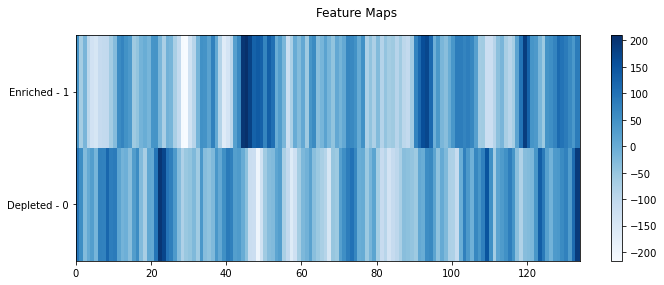

In [25]:
for layer_name, feature_map in zip(layer_names, feature_maps):

    if layer_name == 'attention2':
#         print(feature_map)
        feature_map -= feature_map.mean()
        feature_map /= feature_map.std ()
#         print(f'layer_name: {layer_name}')
#         print(f'feature_map.shape: {feature_map.shape}')
        feature_map_ones = feature_map[ones]
        feature_map_zeros = feature_map[zeros]
#         print(f'feature_map_ones.shape: {feature_map_ones.shape}')
#         print(f'feature_map_zeros.shape: {feature_map_zeros.shape}')
        feature_map_avg_ones = feature_map_ones.sum(axis=0)
        feature_map_avg_zeros = feature_map_zeros.sum(axis=0)
        plot_feature_map(feature_map_avg_ones, "Feature Map Avg Ones")
        plot_feature_map(feature_map_avg_zeros, "Feature Map Avg Zeros")
        plot_both_feature_maps(feature_map_avg_ones, feature_map_avg_zeros,"Feature Maps") 
